# Day 6: AI/ML maths bridge

**Sun, Oct 11 · Prep · about 60 minutes**

The course's 'AI' half reuses exactly the maths from Days 2–5. Today shows how, so Modules 14–15 (Quantum-AI) feel familiar.

**By the end of this notebook you can:**
- Treat data points as feature vectors and compare them with cosine similarity
- Compute a neural-network layer as y = Wx + b
- Take gradient-descent steps on a loss function
- Turn scores into probabilities with softmax
- See why inner products link classical ML and quantum kernels

> How to use this notebook: read each explanation, run the cell under it, then change the numbers and run it again.
> The exercises at the end have a "your turn" cell and a hidden worked solution. Try first, then check.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (5, 5), "axes.grid": True, "grid.alpha": 0.3})

def tex(label):
    """Typeset a ket label like '|+>' as a proper |+⟩ in plots."""
    if label.startswith("|") and label.endswith(">"):
        return r"$|" + label[1:-1] + r"\rangle$"
    return label
rng = np.random.default_rng(0)

## 1. Data points are vectors
A house might be (area, bedrooms, age). A sentence embedding might be 1,536 numbers. Either way it's a vector, and **similarity is an inner product**.

**Cosine similarity** = ⟨u, v⟩ / (‖u‖‖v‖): 1 means the same direction, 0 means unrelated (orthogonal), −1 means opposite.

In [2]:
def cosine(u, v):
    return (u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))

cat = np.array([0.9, 0.8, 0.1]); kitten = np.array([0.85, 0.9, 0.15]); car = np.array([0.1, 0.05, 0.95])
print("cat~kitten:", round(cosine(cat, kitten), 3), "  cat~car:", round(cosine(cat, car), 3))

cat~kitten: 0.996   cat~car: 0.195


## 2. A neural-network layer is a matrix times a vector
A layer with 3 inputs and 2 outputs has a 2×3 weight matrix W and a bias b:  **y = W x + b**.
Each output neuron is one row of W dotted with the input: Day 3 again.

y = [-0.2   0.55]


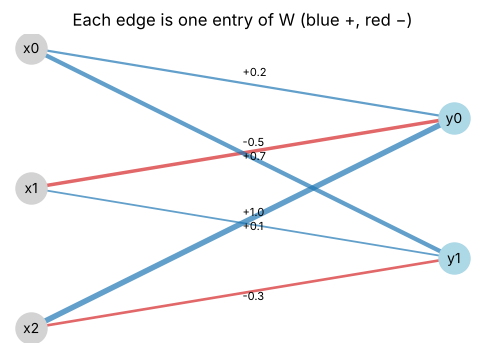

In [3]:
W = np.array([[0.2, -0.5, 1.0],
              [0.7,  0.1, -0.3]])
b = np.array([0.1, -0.2])
x = np.array([1.0, 2.0, 0.5])
y = W @ x + b
print("y =", y)

# draw the layer
fig, ax = plt.subplots(figsize=(6, 4))
ins = [(0, 2 - i) for i in range(3)]; outs = [(2, 1.5 - i) for i in range(2)]
for j, (ox, oy) in enumerate(outs):
    for i, (ix, iy) in enumerate(ins):
        w = W[j, i]
        ax.plot([ix, ox], [iy, oy], color="C0" if w > 0 else "C3", lw=1 + 3 * abs(w), alpha=0.7)
        ax.text((ix + ox) / 2, (iy + oy) / 2 + 0.05 * (1 if j == 0 else -1), f"{w:+.1f}", fontsize=8)
for i, (px, py) in enumerate(ins): ax.scatter(px, py, s=500, c="lightgray", zorder=3); ax.text(px, py, f"x{i}", ha="center", va="center", zorder=4)
for j, (px, py) in enumerate(outs): ax.scatter(px, py, s=500, c="lightblue", zorder=3); ax.text(px, py, f"y{j}", ha="center", va="center", zorder=4)
ax.axis("off"); ax.set_title("Each edge is one entry of W (blue +, red −)"); plt.show()

## 3. Learning = going downhill on a loss
Training adjusts weights to reduce a **loss** L(w). The **gradient** dL/dw points uphill, so we step the other way:

**w ← w − η · dL/dw**   (η is the learning rate)

Example: L(w) = (w − 3)², minimum at w = 3. Its derivative is dL/dw = 2(w − 3).

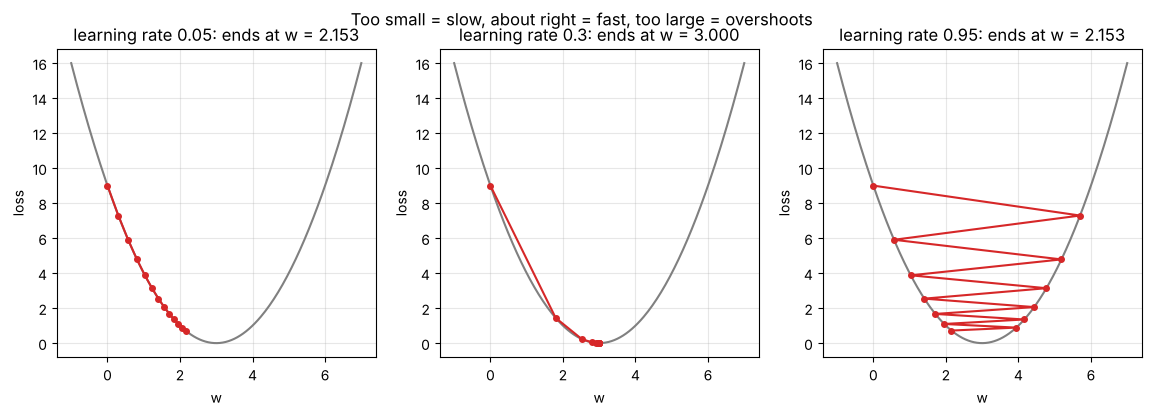

In [4]:
def L(w): return (w - 3) ** 2
def dL(w): return 2 * (w - 3)

def descend(w0, lr, steps=12):
    ws = [w0]
    for _ in range(steps):
        ws.append(ws[-1] - lr * dL(ws[-1]))
    return np.array(ws)

grid = np.linspace(-1, 7, 200)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, lr in zip(axes, [0.05, 0.3, 0.95]):
    ws = descend(0.0, lr)
    ax.plot(grid, L(grid), color="gray"); ax.plot(ws, L(ws), "o-", color="C3", ms=4)
    ax.set_title(f"learning rate {lr}: ends at w = {ws[-1]:.3f}"); ax.set_xlabel("w"); ax.set_ylabel("loss")
plt.suptitle("Too small = slow, about right = fast, too large = overshoots"); plt.show()

## 4. Softmax: scores → probabilities
A classifier outputs raw scores (logits). **Softmax** turns them into a distribution: pₖ = e^(sₖ) / Σ e^(sⱼ).
All outputs are positive and they sum to 1, just like Day 5.

softmax: [0.6652 0.2447 0.09  ]  sum: 0.9999999999999999


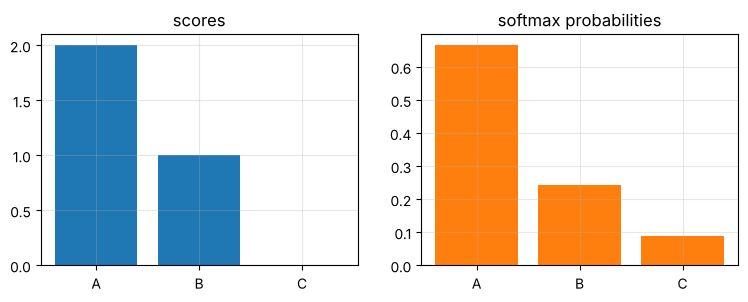

In [5]:
def softmax(s):
    e = np.exp(s - np.max(s))   # subtract max for numerical stability
    return e / e.sum()

scores = np.array([2.0, 1.0, 0.0])
p = softmax(scores)
print("softmax:", p, " sum:", p.sum())
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3))
a1.bar(["A", "B", "C"], scores); a1.set_title("scores")
a2.bar(["A", "B", "C"], p, color="C1"); a2.set_title("softmax probabilities"); plt.show()

## 5. The bridge to quantum-AI
Classical kernel methods (like an SVM) compare data points through inner products ⟨φ(x), φ(x')⟩ of transformed feature vectors.
A **quantum kernel** does the same thing, except φ(x) is a quantum state and the inner product is estimated on a quantum computer.
That's the QSVM in Module 15. Everything you practised on Day 2 carries straight over.

## Exercises
**E1.** Take one gradient-descent step on L(w) = (w − 3)² from w = 0 with learning rate 0.1.

**E2.** Compute softmax(2, 1, 0) to 3 decimal places.

**E3.** For W and b above, which input change raises y₀ the most: +1 on x₀, x₁ or x₂? (Hint: look at row 0 of W.)

In [6]:
# Your turn

<details>
<summary><b>Show worked solution</b></summary>

**E1.** dL/dw at w = 0 is 2(0 − 3) = −6. New w = 0 − 0.1 × (−6) = **0.6**. The loss drops from 9 to (0.6 − 3)² = 5.76.

**E2.** e² = 7.389, e¹ = 2.718, e⁰ = 1, total 11.107. Softmax ≈ **(0.665, 0.245, 0.090)**.

**E3.** Row 0 of W is (0.2, −0.5, 1.0); the biggest positive weight is on **x₂**, so +1 on x₂ raises y₀ by 1.0.

</details>

In [7]:
assert np.isclose(0 - 0.1 * dL(0), 0.6)
assert np.allclose(softmax(np.array([2.0, 1.0, 0.0])), [0.665, 0.245, 0.090], atol=1e-3)
assert np.argmax(W[0]) == 2
print("All Day 6 checks passed.")

All Day 6 checks passed.


---
### Recap checklist
Tick these off in your head before moving on. If any feel shaky, re-run the relevant section with your own numbers.

**Next:** Day 7 (intro): Qubits and Dirac notation

*Part of the IIT Delhi CEP Applied Quantum Computing & AI prep plan: [prep-plan.md](../plan/prep-plan.md)*